# 01 · Data exploration

Goal: understand what the public corpus actually annotates, settle the working taxonomy, and
justify why no real PII is used.

**Sources**
1. `ai4privacy/pii-masking-300k` (Hugging Face) — synthetic corpus with character offsets.
2. Synthetic business documents generated with Faker (ES/EN), with exact ground truth.

Neither contains data from real people.

In [1]:
import sys, json, collections
from pathlib import Path
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt

from pii_pipeline.entities import (
    PII_TYPES, MODEL_TYPES, TYPES_WITHOUT_CORPUS_SUPPORT,
    AI4PRIVACY_LABEL_MAP, INTENTIONALLY_DROPPED, BIO_LABELS, MODEL_BIO_LABELS,
)
DATA = Path('../data')
print(f'Working taxonomy: {len(PII_TYPES)} classes')
print(PII_TYPES)

Working taxonomy: 12 classes
['PERSON', 'EMAIL', 'PHONE', 'ADDRESS', 'DATE_OF_BIRTH', 'CREDIT_CARD', 'BANK_ACCOUNT', 'GOV_ID', 'USERNAME', 'CREDENTIAL', 'IP_ADDRESS', 'DATE_TIME']


## 1. The real label inventory

First lesson of the project: **do not take the dataset documentation at face value.** The real
vocabulary of `privacy_mask` does not match the names you would expect (`GIVENNAME1`, `LASTNAME1`,
`TEL`, `BOD`, `PASS`…). A first version of the mapping assumed standard names and left PERSON,
PHONE, CREDENTIAL and DATE_OF_BIRTH with **zero examples**, without a single error being raised.

In [2]:
import pyarrow.parquet as pq

counts, examples = collections.Counter(), {}
for f in ['ai4privacy_train.parquet', 'ai4privacy_validation.parquet']:
    table = pq.read_table(DATA / 'raw' / f)
    for batch in table.to_batches(max_chunksize=4096):
        for row in batch.to_pylist():
            for m in row['privacy_mask'] or []:
                lab = m['label'].upper()
                counts[lab] += 1
                examples.setdefault(lab, m['value'])

inventory = pd.DataFrame([
    {'label': lab, 'n': n, 'example': str(examples[lab])[:34],
     'mapped_to': AI4PRIVACY_LABEL_MAP.get(lab, '(unmapped)') or 'O (dropped)'}
    for lab, n in counts.most_common()
])
print(f'{len(counts)} distinct labels, {sum(counts.values()):,} annotated spans')
inventory

28 distinct labels, 484,548 annotated spans


,label,n,example,mapped_to
0,TIME,37395,10:20am,DATE_TIME
1,USERNAME,27031,wynqvrh053,USERNAME
2,IDCARD,24920,KB90324ER,GOV_ID
3,SOCIALNUMBER,24404,996 076 6460,GOV_ID
4,EMAIL,24234,bballoi@yahoo.com,EMAIL
5,PASSPORT,23130,301025226,GOV_ID
6,DRIVERLICENSE,22791,LOUMA.657200.9.504,GOV_ID
7,BOD,21924,"Feb 8, 1986",DATE_OF_BIRTH
8,LASTNAME1,21684,Balloi,PERSON
9,IP,20734,7836:3dcf:9edf:692:fd5f:4de5:a9d6:,IP_ADDRESS


## 2. Two classes with no support in the corpus

`CARDISSUER` appears 22 times and annotates the card *brand*, not the number. **There is not a
single card number or bank account number in the entire corpus.**

A design consequence taken explicitly rather than by inventing training signal:

- The model trains on the **10 classes that do exist**.
- `CREDIT_CARD` and `BANK_ACCOUNT` are covered by the **rule engine**, which is superior for these
  types anyway: Luhn and the IBAN mod-97 are arithmetic proofs, not estimates.

In [3]:
print('Model classes        :', MODEL_TYPES)
print('Delegated to rules   :', sorted(TYPES_WITHOUT_CORPUS_SUPPORT))
print('Model BIO space      :', len(MODEL_BIO_LABELS), 'labels')
print()
print('Dropped on purpose:')
for lab, reason in INTENTIONALLY_DROPPED.items():
    print(f'  {lab:14s} {reason}')

Model classes        : ['PERSON', 'EMAIL', 'PHONE', 'ADDRESS', 'DATE_OF_BIRTH', 'GOV_ID', 'USERNAME', 'CREDENTIAL', 'IP_ADDRESS', 'DATE_TIME']
Delegated to rules   : ['BANK_ACCOUNT', 'CREDIT_CARD']
Model BIO space      : 21 labels

Dropped on purpose:
  TITLE          honorific (Mr./Sra.); not identifying on its own
  SEX            demographic attribute, not a direct identifier
  COUNTRY        too coarse to identify a person
  CARDISSUER     brand of the card issuer, not the card number


## 3. Split distribution

,n_documents,n_entities,documents_without_pii
train,40000,230298,4847
validation,5000,28487,641
test,6000,34800,718


,train,validation,test
ADDRESS,53771,6850,8179
GOV_ID,50657,6256,7871
DATE_TIME,28630,3585,4313
PERSON,28474,3498,4219
USERNAME,14693,1693,2131
EMAIL,12945,1573,1979
DATE_OF_BIRTH,11862,1436,1689
IP_ADDRESS,11213,1395,1673
PHONE,10087,1232,1546
CREDENTIAL,7966,969,1200


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


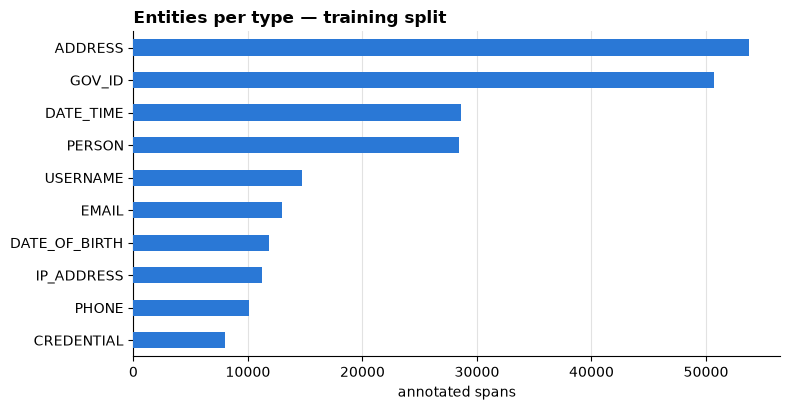

In [4]:
report = json.loads((DATA / 'processed' / 'dataset_report.json').read_text())
splits = pd.DataFrame(report['splits']).T[['n_documents', 'n_entities', 'documents_without_pii']]
display(splits)

by_type = pd.DataFrame({s: report['splits'][s]['by_type'] for s in report['splits']}).fillna(0).astype(int)
display(by_type)

fig, ax = plt.subplots(figsize=(8, 4.2))
by_type['train'].sort_values().plot.barh(ax=ax, color='#2a78d6', zorder=3)
ax.set_title('Entities per type — training split', loc='left', fontweight='600')
ax.set_xlabel('annotated spans')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', color='#e2e2e2', linewidth=.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Languages are balanced on purpose (50/50 ES/EN): the model is multilingual, and an imbalance would
let the aggregate metric hide poor Spanish performance.

In [5]:
pd.DataFrame({s: report['splits'][s]['by_language'] for s in report['splits']})

,train,validation,test
es,19991,2509,3000
en,20009,2491,3000


## 4. Annotations dropped for inconsistent offsets

The corpus ships spans whose offsets do not line up with the text. They are dropped: training on
them would be teaching the model noise.

In [6]:
dropped = report['dropped_source_labels']['counts']
bad = {k: v for k, v in dropped.items() if k.startswith('__')}
print(f'Annotations dropped for invalid offsets: {sum(bad.values()):,}')
pd.Series(bad).sort_values(ascending=False).head(10)

Annotations dropped for invalid offsets: 2,053


__offset_mismatch__PASS             351
__offset_mismatch__TIME             151
__offset_mismatch__IDCARD           149
__offset_mismatch__USERNAME         134
__offset_mismatch__PASSPORT         126
__offset_mismatch__GIVENNAME1       114
__offset_mismatch__LASTNAME1        110
__offset_mismatch__DRIVERLICENSE     94
__offset_mismatch__EMAIL             88
__offset_mismatch__BOD               87
dtype: int64

## 5. The synthetic corpus of complete documents

The public corpus is isolated sentences. Real redaction happens on **documents**, where layout,
field labels and repeated mentions all matter.

Five document types are generated (invoice, contract, email, ticket, form) in ES and EN. The trick:
the document is assembled through a *builder* that records the offset of every PII value **as it is
written**, so the annotation is exact by construction and needs no manual labelling.

**Distractors** are also inserted (`ORD-…`, `SKU-…`, amounts) that *look* like identifiers but are
left unannotated — they are what makes over-redaction honestly measurable.

In [7]:
docs = [json.loads(l) for l in (DATA / 'synthetic' / 'documents.jsonl').read_text().splitlines()]
print(f'{len(docs)} documents, {sum(len(d["entities"]) for d in docs):,} entities')
display(pd.crosstab([d['doc_type'] for d in docs], [d['lang'] for d in docs]))

ejemplo = next(d for d in docs if d['doc_type'] == 'onboarding_form' and d['lang'] == 'es')
print(ejemplo['text'][:700])

300 documents, 3,000 entities


col_0,en,es
row_0,,
contract,30,30
email,30,30
invoice,30,30
onboarding_form,30,30
support_ticket,30,30


FORMULARIO DE ALTA DE CLIENTE
Referencia interna: ORD-517225

Nombre y apellidos: Raquel Ferrández
Fecha de nacimiento: 04/12/1985
Documento de identidad: 26670364R
Dirección: Via de Rosario Sarmiento 546
Ciudad: Las Palmas    Código postal: 26507
Teléfono móvil: +34 942 51 23 30
Correo electrónico: rferrández@gervasio.com
Cuenta para domiciliación: ES3478720097447379727611
Usuario deseado: rferrández46
Contraseña provisional: _(z6mUyOwz0k

Declaro que los datos son veraces y autorizo su tratamiento conforme al RGPD.



In [8]:
# Integrity check: every offset must recover exactly its value.
malos = [(d['id'], e) for d in docs for e in d['entities']
         if d['text'][e['start']:e['end']] != e['text']]
print(f'Inconsistent offsets: {len(malos)}  (must be 0)')

Inconsistent offsets: 0  (must be 0)


## Conclusions

1. The corpus's real vocabulary forced a rewrite of the mapping; the dropped-label report is part of
   the deliverable so that the decision stays auditable.
2. Two of the 12 classes have no support in the corpus → **hybrid** architecture: a model for free
   text, checksum-backed rules for structured identifiers.
3. The synthetic document corpus is the test set that genuinely predicts production behaviour,
   because it introduces *domain shift* relative to training.